Tadas Riksas 2312087 convnext_large Zebra Banana Parachute

In [1]:
pip install --user torch torchvision scikit-image numpy matplotlib==3.10.8 pandas openimages

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
from torch import Generator
import torch
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from openimages.download import download_dataset
import torchvision.models as models
import glob
import torch.nn as nn   
from PIL import Image

In [30]:
data_dir = "./project/data/"

# TODO - increase in production
number_of_samples = 334
classes = ["Ambulance", "Banana", "Parachute"]
mappings = [407, 954, 701]

NUM_CLASSES = len(classes)

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
print("Downloading data...")
download_dataset(
    data_dir,
    classes,
    limit=number_of_samples,
)

2026-03-15  20:24:54 INFO Downloading 207 train images for class 'ambulance'
100%|██████████| 207/207 [00:09<00:00, 22.07it/s]
2026-03-15  20:25:12 INFO Downloading 334 train images for class 'banana'
100%|██████████| 334/334 [00:14<00:00, 23.16it/s]
2026-03-15  20:25:26 INFO Downloading 334 train images for class 'parachute'
100%|██████████| 334/334 [00:13<00:00, 24.98it/s]
2026-03-15  20:25:41 INFO Downloading 8 validation images for class 'ambulance'
100%|██████████| 8/8 [00:01<00:00,  5.51it/s]
2026-03-15  20:25:46 INFO Downloading 40 test images for class 'ambulance'
100%|██████████| 40/40 [00:03<00:00, 11.97it/s]


{'ambulance': {'images_dir': './project/data/ambulance/images'},
 'banana': {'images_dir': './project/data/banana/images'},
 'parachute': {'images_dir': './project/data/parachute/images'}}

In [31]:
IMAGE_SIZE = 380

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [32]:
def read_img(file_name):
    return Image.open(file_name).convert("RGB")

In [33]:
class MyImages(Dataset):
    def __init__(self, path, augment=False):
        self.path = path
        self.images = os.listdir(path)
        self.augment = augment

        self.class1_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[0].lower()))
        self.class2_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[1].lower()))
        self.class3_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[2].lower()))
        
        # include only the number of samples specified
        self.class1_files = self.class1_files[:number_of_samples]
        self.class2_files = self.class2_files[:number_of_samples]
        self.class3_files = self.class3_files[:number_of_samples]
        
        self.class1 = len(self.class1_files)
        self.class2 = len(self.class2_files)
        self.class3 = len(self.class3_files)
        
        self.files = self.class1_files + self.class2_files + self.class3_files
        
        self.labels = [0] * self.class1 + [1] * self.class2 + [2] * self.class3
        
        self.order = [x for x in np.random.permutation(len(self.files))]
        self.files = [self.files[i] for i in self.order]
        self.labels = [self.labels[i] for i in self.order]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = read_img(self.files[idx])
        label = self.labels[idx]
        
        transform = augment_transform if self.augment else base_transform
        img = transform(img)
        return img, label


In [34]:
TRAIN_SPLIT = 0.7
SEED = 1
BATCH_SIZE = 32

def get_dataloaders():
    # splitting the data into train and validation set
    
    full_dataset = MyImages(data_dir, augment=False)
    
    train_size = int(TRAIN_SPLIT * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    train_dataset = MyImages(data_dir, augment=True)
    val_dataset = MyImages(data_dir, augment=False)
    
    train_ds, _ = random_split(train_dataset, [train_size, val_size], generator=Generator().manual_seed(SEED))
    _, val_ds = random_split(val_dataset, [train_size, val_size], generator=Generator().manual_seed(SEED))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
    
    return train_loader, val_loader

In [35]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out
        
        
class MiniResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x
    
        
        

In [36]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "best_model.pth"

def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    training_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []
    
    best_val_acc = 0.0
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        train_loss = running_loss / total_train
        train_accuracy = correct_train / total_train
        
        # Validation loop
        running_loss_v = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(DEVICE)
                labels  = labels.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                running_loss_v += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = running_loss_v / total_val
        val_acc = correct_val / total_val
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            
        training_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_accuracy)
        val_acc_history.append(val_acc)
    
    return (training_loss_history, val_loss_history, train_acc_history, val_acc_history)


In [37]:
train_loader, val_loader = get_dataloaders()
model = MiniResNet().to(DEVICE)
history = train_model(model, train_loader, val_loader)

In [38]:
def plot_training_history(history):
    training_loss_history, val_loss_history, train_acc_history, val_acc_history = history
    
    epochs = range(1, NUM_EPOCHS + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, training_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_history, label='Training Accuracy')
    plt.plot(epochs, val_acc_history, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

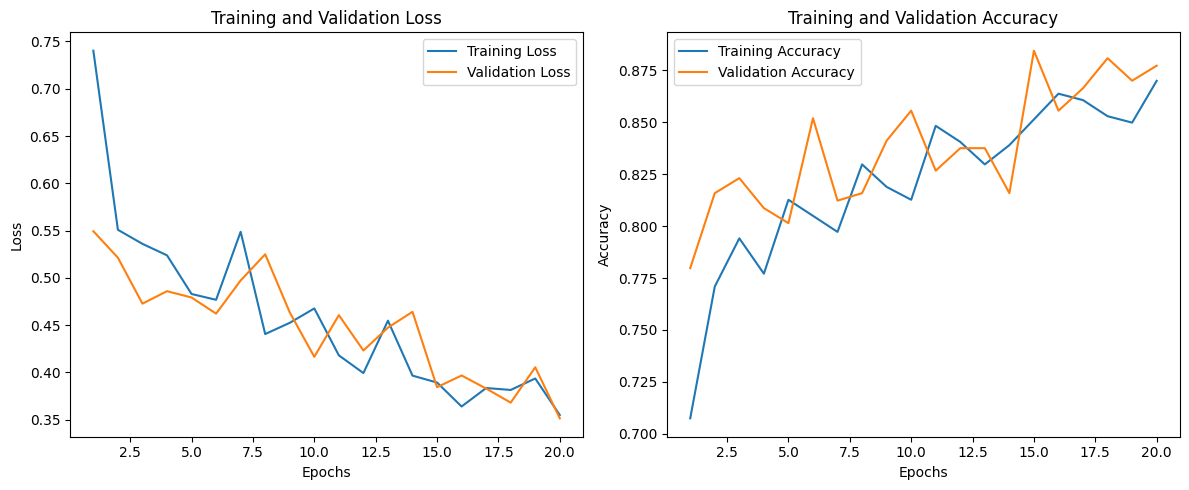

In [39]:
plot_training_history(history)

In [40]:
    
dataset = MyImages(data_dir, augment=False)
dataloader = DataLoader(dataset, 
                        batch_size=256, 
                        shuffle=True,
                        num_workers=4,
                        pin_memory=True,
                        prefetch_factor=2)



model = MiniResNet(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

model.to(DEVICE)

all_predictions = []
all_labels = []
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.nn.functional.sigmoid(outputs)
        all_predictions.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

print("Predictions shape:", np.concatenate(all_predictions).shape)
print("Labels shape:", np.concatenate(all_labels).shape)

Predictions shape: (923, 3)
Labels shape: (923,)


In [41]:

def classify_with_threshold(predictions, true_labels, class_idx: int, threshold=0.5):
    """
    Classify samples based on threshold for a specific class
    # """
    class_probs = predictions[:, class_idx]
    predicted = (class_probs >= threshold).astype(int)
    true = (true_labels == class_idx).astype(int)
    
    # Calculate metrics
    tp = np.sum((predicted == 1) & (true == 1))
    fp = np.sum((predicted == 1) & (true == 0))
    fn = np.sum((predicted == 0) & (true == 1))
    tn = np.sum((predicted == 0) & (true == 0))
    
    accuracy = (tp + tn) / len(true) if len(true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [44]:

all_predictions_concat = np.concatenate(all_predictions)
all_labels_concat = np.concatenate(all_labels)
T_list = np.concatenate([
    np.linspace(0.05, 0.7, 15),  
    np.linspace(0.7, 1, 15),
])
results = {class_name: [] for class_name in classes}

for j in range(3):
    for T in T_list:
        metrics = classify_with_threshold(
            all_predictions_concat, 
            all_labels_concat, 
            j,
            threshold=T
        )
        results[classes[j]].append(metrics['f1'])
    
    # Find optimal threshold
    idx = np.argmax(results[classes[j]])
    print(f"Optimal T={T_list[idx]:.2f} for {classes[j]} (F1={results[classes[j]][idx]:.3f})")

Optimal T=0.61 for Ambulance (F1=0.884)
Optimal T=0.61 for Banana (F1=0.878)
Optimal T=0.70 for Parachute (F1=0.905)


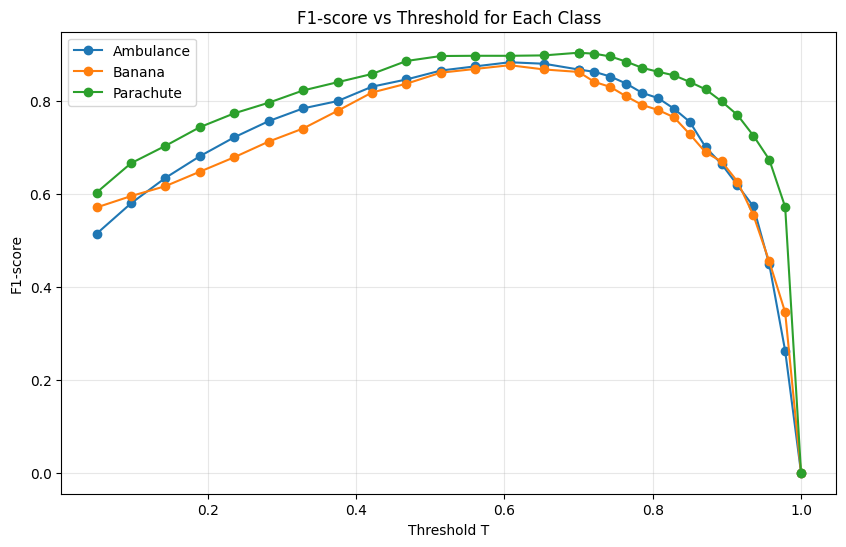

In [46]:
plt.figure(figsize=(10, 6))

for class_name in classes:
    plt.plot(T_list, results[class_name], marker='o', label=class_name)

plt.xlabel("Threshold T")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold for Each Class")
plt.legend()
plt.grid(True, alpha=0.3)
# limit y above 0.5 for better visualization
# plt.ylim(0.45, 1)
# plt.tight_layout()
plt.show()

In [47]:

# print(all_labels_concat[:10])
# print(all_predictions_concat[:, mappings][:10])
# print([np.max(all_predictions_concat[i]) for i in range(10)])

# # select classes with max probability
# for i in range(10):
#     predicted_class_idx = np.argmax(all_predictions_concat[i])
#     print(predicted_class_idx)

[1 1 1 1 1 1 1 1 1 1]


IndexError: index 407 is out of bounds for axis 1 with size 3

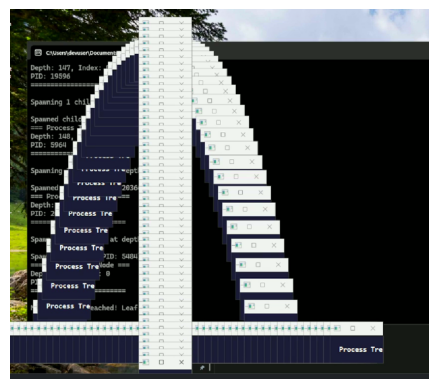

[[0.9942357  0.21032387 0.00647863]]


In [48]:
# select one image not from the training set and test the model on it
# download an image of a house
# spec_img = "./project/train-station.jpg"
# spec_img = "./project/fundog.png"
# spec_img = "./project/bugdog.webp"
# spec_img = "./project/winfun.png"
spec_img = "./project/winfun.png"
image = io.imread(spec_img)
plt.imshow(image)
plt.axis('off')
plt.show()

# test model on the image
img_tensor = base_transform(read_img(spec_img)).unsqueeze(0).to(DEVICE)
probabilities = model(img_tensor)
probabilities = torch.nn.functional.sigmoid(probabilities)
print(probabilities.detach().cpu().numpy())